# Heat Vulnerability and Cooling Equity in New York City

**Research question:** How are NYC Parks spray showers distributed in relation to neighborhood heat vulnerability, and which high-vulnerability ZCTAs appear to have relatively limited access to this public cooling resource?

This notebook combines:

1. **NYC Heat Vulnerability Index Rankings** by 2020 ZIP Code Tabulation Area (ZCTA)
2. **NYC Parks Spray Showers** point locations
3. **2020 Census ZCTA boundaries**
4. **2020 ACS population estimates** for population-normalized comparison

It includes metadata exploration, three maps, multiple non-map visualizations, numeric summaries, and a discussion of what the selected attributes can and cannot tell us.

### Sources

- [NYC Heat Vulnerability Index Rankings](https://data.cityofnewyork.us/Health/Heat-Vulnerability-Index-Rankings/4mhf-duep)
- [NYC Health HVI explanation](https://a816-dohbesp.nyc.gov/IndicatorPublic/data-features/hvi/)
- [NYC Parks Spray Showers](https://data.cityofnewyork.us/Recreation/NYC-Parks-Spray-Showers/ckaz-6gaa)
- [NYC Parks spray shower information](https://www.nycgovparks.org/facilities/sprayshowers)
- [U.S. Census ZCTA explanation](https://www.census.gov/programs-surveys/geography/guidance/geo-areas/zctas.html)
- [2020 ACS 5-year API](https://api.census.gov/data/2020/acs/acs5.html)

**Accessed:** July 11, 2026

## 1. Setup

The notebook stores downloaded files in `data/` and saves figures and processed data in `outputs/`. The original HVI CSV is used when it is in the same folder as the notebook; otherwise, the notebook downloads the official NYC Open Data version.

In [1]:
# Uncomment only if these packages are missing:
# %pip install pandas geopandas matplotlib requests pyogrio

from pathlib import Path
import time
import warnings
import zipfile

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

HVI_FILENAME = "Heat_Vulnerability_Index_Rankings_20260711.csv"

HVI_URL = (
    "https://data.cityofnewyork.us/api/views/4mhf-duep/rows.csv?accessType=DOWNLOAD"
)
SPRAY_URL = (
    "https://data.cityofnewyork.us/api/v3/views/"
    "ckaz-6gaa/query.geojson?accessType=DOWNLOAD"
)
ZCTA_URL = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_zcta520_500k.zip"
ACS_URL = (
    "https://api.census.gov/data/2020/acs/acs5"
    "?get=NAME,B01003_001E"
    "&for=zip%20code%20tabulation%20area:*"
)


def download_file(url, destination, attempts=3):
    # Download with retry and reuse a cached local file.
    destination = Path(destination)
    if destination.exists() and destination.stat().st_size > 0:
        print("Using cached file:", destination)
        return destination

    last_error = None
    headers = {"User-Agent": "Mozilla/5.0 educational-analysis"}

    for attempt in range(1, attempts + 1):
        try:
            print(f"Downloading {destination.name}: attempt {attempt}/{attempts}")
            with requests.get(
                url, stream=True, timeout=180, headers=headers
            ) as response:
                response.raise_for_status()
                with open(destination, "wb") as f:
                    for chunk in response.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            f.write(chunk)
            return destination
        except Exception as error:
            last_error = error
            time.sleep(2)

    raise RuntimeError(f"Download failed: {url}. Last error: {last_error}")


print("GeoPandas version:", gpd.__version__)
print("Working directory:", Path.cwd())

GeoPandas version: 1.1.3
Working directory: /Users/li/Downloads/Heat_Vulnerability_and_Cooling_Equity_NYC_submission


## 2. Load and inspect the Heat Vulnerability Index

I chose **HVI** because it summarizes relative neighborhood vulnerability to heat-related health effects. NYC Health explains that it combines environmental and social factors such as surface temperature, green space, home air conditioning, and income.

HVI ranges from **1 to 5**, where 1 is the lowest relative vulnerability and 5 is the highest. It is an **ordinal** variable: 5 is higher than 4, but it does not mean five times the vulnerability of 1, and the distance between ranks is not necessarily equal.

In [2]:
possible_files = [
    Path(HVI_FILENAME),
    DATA_DIR / HVI_FILENAME,
    Path("/mnt/data") / HVI_FILENAME,
]

hvi_path = next((p for p in possible_files if p.exists()), None)

if hvi_path is None:
    hvi_path = download_file(
        HVI_URL, DATA_DIR / "Heat_Vulnerability_Index_Rankings.csv"
    )

raw_hvi = pd.read_csv(hvi_path)
raw_hvi.columns = (
    raw_hvi.columns.str.strip().str.upper().str.replace(" ", "_", regex=False)
)

zcta_col = next((c for c in raw_hvi.columns if "ZCTA" in c), None)
hvi_col = next((c for c in raw_hvi.columns if c == "HVI" or "VULNERABILITY" in c), None)

if zcta_col is None or hvi_col is None:
    raise ValueError(f"Could not identify fields. Columns: {raw_hvi.columns.tolist()}")

hvi = raw_hvi.rename(columns={zcta_col: "ZCTA", hvi_col: "HVI"})[["ZCTA", "HVI"]].copy()

hvi["ZCTA"] = hvi["ZCTA"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(5)
hvi["HVI"] = pd.to_numeric(hvi["HVI"], errors="coerce")
hvi = hvi.dropna().drop_duplicates("ZCTA")
hvi["HVI"] = hvi["HVI"].astype(int)

print("Source:", hvi_path)
print("Rows:", len(hvi))
print("Unique ZCTAs:", hvi["ZCTA"].nunique())
print("Missing values:", hvi.isna().sum().to_dict())
display(hvi.head())
display(hvi["HVI"].value_counts().sort_index().rename("ZCTA count").to_frame())

Source: Heat_Vulnerability_Index_Rankings_20260711.csv
Rows: 184
Unique ZCTAs: 184
Missing values: {'ZCTA': 0, 'HVI': 0}


,ZCTA,HVI
0,10465,1
1,10310,3
2,11203,5
3,11224,5
4,11212,5


,ZCTA count
HVI,
1,37
2,37
3,36
4,37
5,37


### What HVI can tell us

HVI can compare relative heat vulnerability across NYC, show spatial clustering, and help identify communities that may warrant priority outreach or investment.

### What HVI cannot tell us

HVI cannot identify an individual's risk, show real-time weather, predict an exact number of deaths or hospitalizations, or establish that one factor caused a neighborhood's rank. A lower HVI also does not mean that a neighborhood has no heat risk.

## 3. Load 2020 Census ZCTA boundaries

The HVI table has identifiers but no geometry. I join it to 2020 Census ZCTA polygons. ZCTAs approximate USPS ZIP Code areas but are not identical to postal delivery ZIP Codes or socially defined neighborhoods.

In [3]:
zcta_zip = download_file(ZCTA_URL, DATA_DIR / "cb_2020_us_zcta520_500k.zip")

extract_dir = DATA_DIR / "cb_2020_us_zcta520_500k"

if not extract_dir.exists():
    extract_dir.mkdir()
    with zipfile.ZipFile(zcta_zip, "r") as archive:
        archive.extractall(extract_dir)

shp_files = list(extract_dir.glob("*.shp"))
if not shp_files:
    raise FileNotFoundError("No ZCTA shapefile found after extraction.")

zcta_us = gpd.read_file(shp_files[0])

code_candidates = ["ZCTA5CE20", "GEOID20", "GEOID"]
boundary_code = next((c for c in code_candidates if c in zcta_us.columns), None)

if boundary_code is None:
    raise ValueError(f"ZCTA code field not found. Columns: {zcta_us.columns.tolist()}")

zcta_us["ZCTA"] = (
    zcta_us[boundary_code].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(5)
)

zcta_nyc = zcta_us[zcta_us["ZCTA"].isin(hvi["ZCTA"])][["ZCTA", "geometry"]].copy()

print("HVI ZCTAs:", len(hvi))
print("Matched polygons:", len(zcta_nyc))
print("CRS:", zcta_nyc.crs)

missing = sorted(set(hvi["ZCTA"]) - set(zcta_nyc["ZCTA"]))
print("HVI ZCTAs without boundaries:", missing)

HVI ZCTAs: 184
Matched polygons: 184
CRS: EPSG:4269
HVI ZCTAs without boundaries: []


## 4. Load NYC Parks spray showers

I use spray showers as one observable form of free public cooling infrastructure. I analyze:

- raw facility count by ZCTA;
- facilities per square mile;
- facilities per 10,000 residents.

Raw counts favor larger or more populous areas. Normalization improves comparison, but still does not measure actual walking access.

In [4]:
spray_path = download_file(SPRAY_URL, DATA_DIR / "NYC_Parks_Spray_Showers.geojson")

sprays = gpd.read_file(spray_path)

if sprays.crs is None:
    sprays = sprays.set_crs("EPSG:4326")

sprays = sprays[sprays.geometry.notna() & ~sprays.geometry.is_empty].copy()

sprays["spray_id"] = np.arange(len(sprays))

print("Spray shower records:", len(sprays))
print("Geometry types:")
display(sprays.geometry.geom_type.value_counts().to_frame("count"))
print("Fields:", sprays.columns.tolist())
display(sprays.head())

Spray shower records: 1113
Geometry types:


,count
Point,1113


Fields: [':id', ':version', ':created_at', ':updated_at', 'system', 'boro', 'propnum', 'propname', 'propid', 'sitename', 'district', 'coundist', ':@computed_region_f5dn_yrer', ':@computed_region_yeji_bk3q', ':@computed_region_sbqj_enih', ':@computed_region_92fq_4b7q', 'geometry', 'spray_id']


,:id,:version,:created_at,:updated_at,system,boro,propnum,propname,propid,sitename,district,coundist,:@computed_region_f5dn_yrer,:@computed_region_yeji_bk3q,:@computed_region_sbqj_enih,:@computed_region_92fq_4b7q,geometry,spray_id
0,row-gbwn.7k3x_6bjw,rv-bz9r_9stv_hbty,2026-07-05 13:02:15.368000+00:00,2026-07-05 13:02:17.190000+00:00,B228-SPRAY0116,B,B228,Dr. Green Playground,B228,Dr. Green Playground,B-16,41,55,2,46,17,POINT (-73.90758 40.66733),0
1,row-gw4j~6y2t_f8s2,rv-ptns-azed_c5na,2026-07-05 13:02:15.368000+00:00,2026-07-05 13:02:17.190000+00:00,B223B-SPRAY0110,B,B223B,Dimattina Playground,B223B,Dimattina Playground,B-06,39,14,2,48,27,POINT (-74.00202 40.6807),1
2,row-h8rq-f4p8.vbyy,rv-uee3~fpuj.3966,2026-07-05 13:02:15.368000+00:00,2026-07-05 13:02:17.190000+00:00,B237-SPRAY0121,B,B237,John Hancock Playground,B237,John Hancock Playground,B-03,36,69,2,51,49,POINT (-73.95475 40.68224),2
3,row-kv3x.rt4f-9tks,rv-rh6c_dp7q_smnh,2026-07-05 13:02:15.368000+00:00,2026-07-05 13:02:17.190000+00:00,B223H-SPRAY0111,B,B223H,Harry Chapin Playground,B223H,Harry Chapin Playground,B-02,33,68,2,54,38,POINT (-73.99492 40.70066),3
4,row-9vhi_i732_ncw4,rv-drh6~d59u~7zed,2026-07-05 13:02:15.368000+00:00,2026-07-05 13:02:17.190000+00:00,B230-SPRAY0117,B,B230,Nicholas Naquan Heyward Jr. Park,B230,Nicholas Naquan Heyward Jr. Park,B-06,39,14,2,48,38,POINT (-73.98799 40.68458),4


### What the spray-shower data can and cannot tell us

The dataset shows mapped NYC Parks-managed spray shower locations and supports counts or densities by area. It does **not** tell us whether each facility is open, functioning, accessible, well maintained, or large enough for demand. It also excludes cooling centers, libraries, pools, fountains, tree shade, private facilities, and household air conditioning.

Therefore, this notebook analyzes the distribution of **one type of cooling resource**, not complete cooling access.

## 5. Add population and construct the analysis table

I use 2020 ACS total population estimate `B01003_001E` to calculate facilities per 10,000 residents. ACS values are estimates with uncertainty; this notebook does not analyze margins of error.

For area calculations, I project the data to **EPSG:2263**, a New York-area coordinate system measured in feet.

In [5]:
population_available = True

try:
    response = requests.get(
        ACS_URL, timeout=180, headers={"User-Agent": "Mozilla/5.0 educational-analysis"}
    )
    response.raise_for_status()
    rows = response.json()

    population = pd.DataFrame(rows[1:], columns=rows[0]).rename(
        columns={"B01003_001E": "population_2020", "zip code tabulation area": "ZCTA"}
    )
    population["ZCTA"] = population["ZCTA"].astype(str).str.zfill(5)
    population["population_2020"] = pd.to_numeric(
        population["population_2020"], errors="coerce"
    )
    population = population[["ZCTA", "population_2020"]].drop_duplicates("ZCTA")
    population.to_csv(DATA_DIR / "ACS_2020_ZCTA_population.csv", index=False)

except Exception as error:
    cached = DATA_DIR / "ACS_2020_ZCTA_population.csv"
    if cached.exists():
        population = pd.read_csv(cached, dtype={"ZCTA": str})
        population["ZCTA"] = population["ZCTA"].str.zfill(5)
        print("Using cached population data.")
    else:
        population_available = False
        population = pd.DataFrame(columns=["ZCTA", "population_2020"])
        print("Population data unavailable:", error)

analysis = zcta_nyc.merge(hvi, on="ZCTA", how="inner", validate="one_to_one")
analysis = analysis.to_crs("EPSG:2263")
sprays_projected = sprays.to_crs(analysis.crs)

joined = gpd.sjoin(
    sprays_projected, analysis[["ZCTA", "geometry"]], how="left", predicate="within"
)

counts = (
    joined.dropna(subset=["ZCTA"])
    .groupby("ZCTA")["spray_id"]
    .nunique()
    .rename("spray_shower_count")
    .reset_index()
)

analysis = analysis.merge(counts, on="ZCTA", how="left")
analysis["spray_shower_count"] = analysis["spray_shower_count"].fillna(0).astype(int)
analysis["area_sq_mile"] = analysis.geometry.area / 27_878_400
analysis["spray_showers_per_sq_mile"] = (
    analysis["spray_shower_count"] / analysis["area_sq_mile"]
)

if population_available:
    analysis = analysis.merge(population, on="ZCTA", how="left")
    analysis["spray_showers_per_10k"] = np.where(
        analysis["population_2020"] > 0,
        analysis["spray_shower_count"] / analysis["population_2020"] * 10_000,
        np.nan,
    )
else:
    analysis["population_2020"] = np.nan
    analysis["spray_showers_per_10k"] = np.nan

analysis_map = analysis.to_crs("EPSG:4326")
sprays_map = sprays_projected.to_crs("EPSG:4326")

print("Matched spray points:", joined["ZCTA"].notna().sum())
print("Unmatched spray points:", joined["ZCTA"].isna().sum())

display(
    analysis[
        [
            "ZCTA",
            "HVI",
            "spray_shower_count",
            "area_sq_mile",
            "population_2020",
            "spray_showers_per_sq_mile",
            "spray_showers_per_10k",
        ]
    ].head()
)

Population data unavailable: Expecting value: line 2 column 1 (char 1)
Matched spray points: 1102
Unmatched spray points: 11


,ZCTA,HVI,spray_shower_count,area_sq_mile,population_2020,spray_showers_per_sq_mile,spray_showers_per_10k
0,10037,5,7,0.23,NaN,30.12,NaN
1,11414,2,3,2.37,NaN,1.27,NaN
2,10473,4,6,2.14,NaN,2.80,NaN
3,10036,2,6,0.44,NaN,13.60,NaN
4,11355,4,9,1.72,NaN,5.22,NaN


## 6. Map 1: Heat Vulnerability Index

Because HVI is ordinal, it is displayed as five discrete categories rather than treated as a continuous physical measurement.

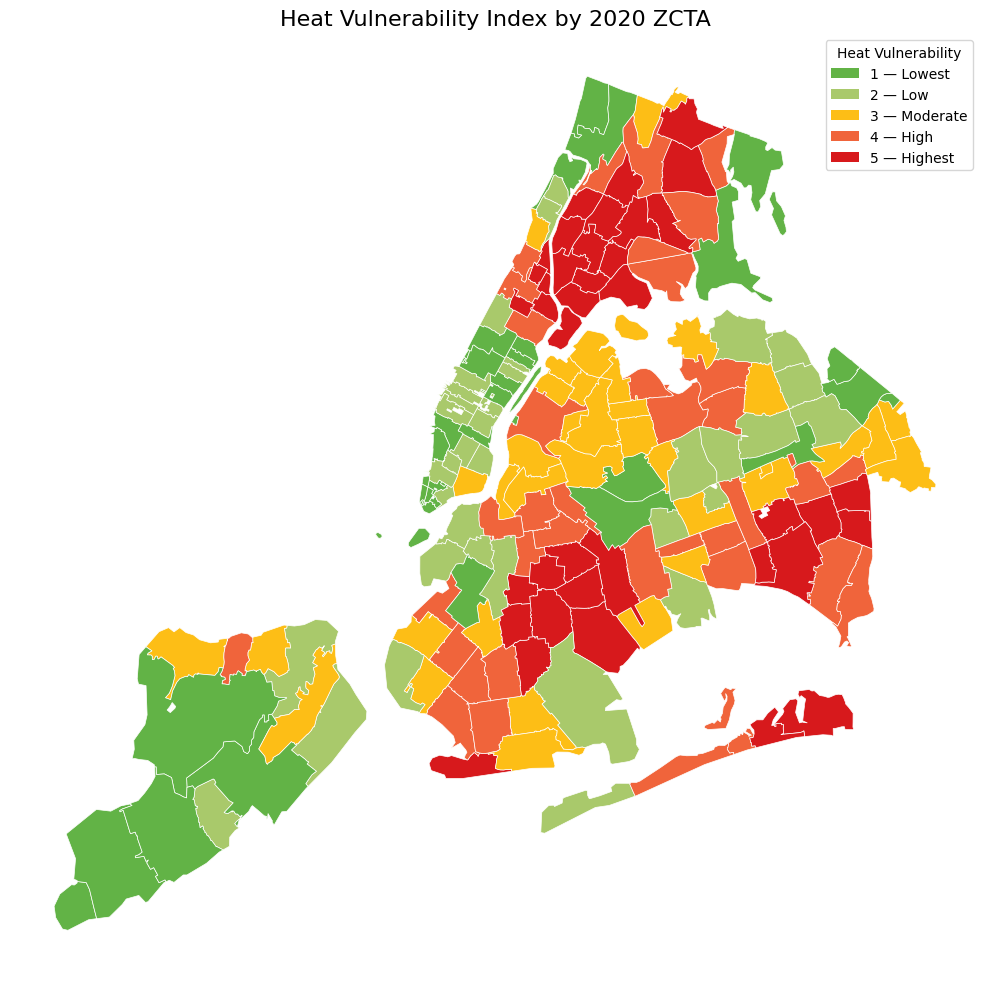

In [20]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# HVI 1–5: green → light green → yellow → orange → red
hvi_colors = [
    "#62B346",  # 1 - Lowest
    "#A9C96B",  # 2
    "#FDBE16",  # 3
    "#F0643B",  # 4
    "#D7191C",  # 5 - Highest
]

hvi_cmap = ListedColormap(hvi_colors)

fig, ax = plt.subplots(figsize=(10, 10))

analysis_map.plot(
    column="HVI",
    cmap=hvi_cmap,
    categorical=True,
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
)

# Custom legend
legend_items = [
    Patch(facecolor=hvi_colors[0], label="1 — Lowest"),
    Patch(facecolor=hvi_colors[1], label="2 — Low"),
    Patch(facecolor=hvi_colors[2], label="3 — Moderate"),
    Patch(facecolor=hvi_colors[3], label="4 — High"),
    Patch(facecolor=hvi_colors[4], label="5 — Highest"),
]

ax.legend(
    handles=legend_items, title="Heat Vulnerability", loc="upper right", frameon=True
)

ax.set_title("Heat Vulnerability Index by 2020 ZCTA", fontsize=16)

ax.set_axis_off()

plt.tight_layout()


plt.show()

## 7. Map 2: HVI and spray-shower locations

This overlay supports an initial visual comparison of community-level need and facility locations. Point clustering alone does not establish equity because ZCTAs differ in population, size, parks, and street accessibility.

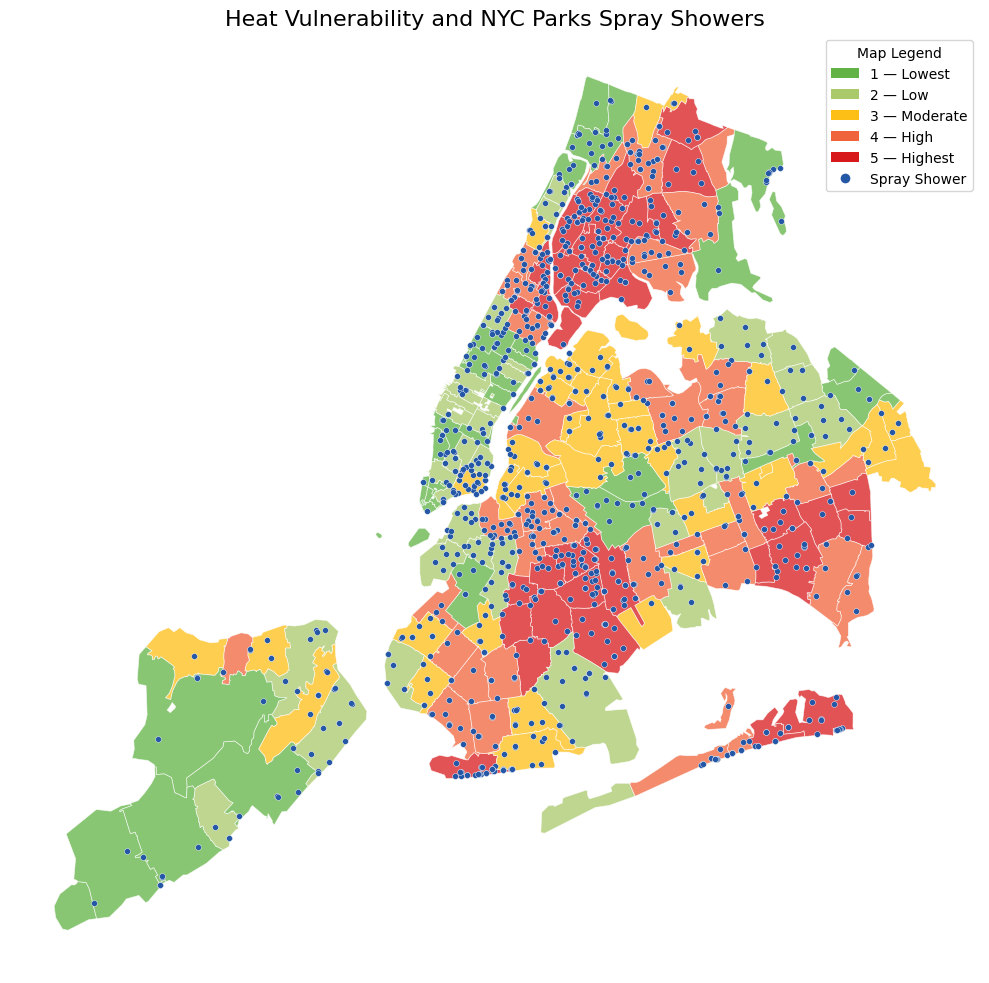

In [23]:
from matplotlib.lines import Line2D

# Same HVI color palette used in Map 1
hvi_colors = [
    "#62B346",  # 1 - Lowest
    "#A9C96B",  # 2 - Low
    "#FDBE16",  # 3 - Moderate
    "#F0643B",  # 4 - High
    "#D7191C",  # 5 - Highest
]

hvi_cmap = ListedColormap(hvi_colors)

fig, ax = plt.subplots(figsize=(10, 10))

# HVI polygons
analysis_map.plot(
    column="HVI",
    cmap=hvi_cmap,
    categorical=True,
    linewidth=0.5,
    edgecolor="white",
    alpha=0.75,
    ax=ax,
)

# Spray shower points
sprays_map.plot(
    ax=ax, color="#2457A6", edgecolor="white", linewidth=0.3, markersize=18, marker="o"
)

# Custom legend
legend_items = [
    Patch(facecolor=hvi_colors[0], edgecolor="none", label="1 — Lowest"),
    Patch(facecolor=hvi_colors[1], edgecolor="none", label="2 — Low"),
    Patch(facecolor=hvi_colors[2], edgecolor="none", label="3 — Moderate"),
    Patch(facecolor=hvi_colors[3], edgecolor="none", label="4 — High"),
    Patch(facecolor=hvi_colors[4], edgecolor="none", label="5 — Highest"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#2457A6",
        markeredgecolor="white",
        markersize=8,
        label="Spray Shower",
    ),
]

ax.legend(handles=legend_items, title="Map Legend", loc="upper right", frameon=True)

ax.set_title("Heat Vulnerability and NYC Parks Spray Showers", fontsize=16)

ax.set_axis_off()

plt.tight_layout()

plt.savefig(OUTPUT_DIR / "02_hvi_and_spray_showers.png", dpi=300, bbox_inches="tight")

plt.show()

The map does not show a clear relationship between HVI and the number of spray showers. This suggests that spray-shower availability alone does not explain neighborhood heat vulnerability. HVI is shaped by a broader combination of environmental and social conditions, including surface temperature, green space, household air-conditioning access, income, and racial inequities. Spray showers may provide localized heat relief, but they represent only one form of cooling infrastructure and are not included directly in the calculation of HVI.

## 8. Map 3: Spray showers per square mile

Area-normalized density reduces the advantage of physically large ZCTAs, but it does not account for population or cross-boundary travel.

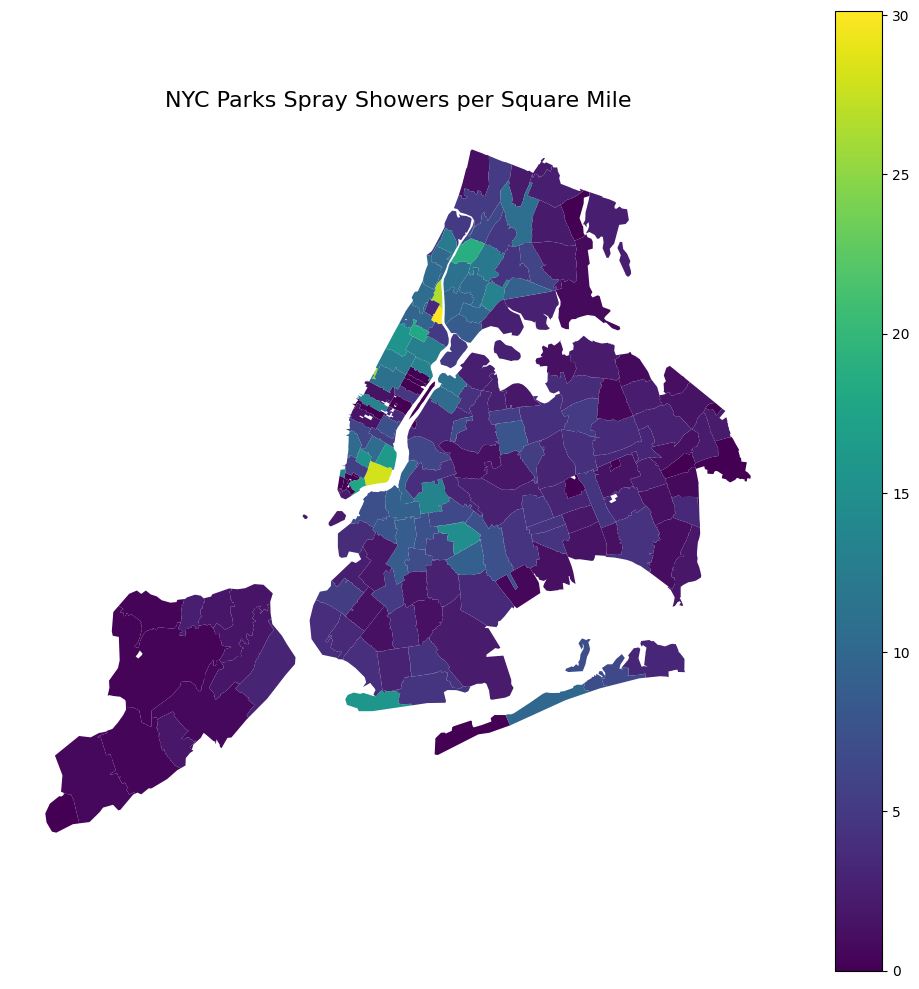

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
analysis_map.plot(
    column="spray_showers_per_sq_mile",
    legend=True,
    linewidth=0.4,
    ax=ax,
    missing_kwds={"label": "Missing"},
)
ax.set_title("NYC Parks Spray Showers per Square Mile", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "03_spray_showers_per_square_mile.png", dpi=300, bbox_inches="tight"
)
plt.show()

## 9. Non-map visualizations

The first chart checks the HVI distribution. Because HVI is ranked relatively, category counts may be close to evenly distributed. A nearly flat chart is therefore expected rather than a major finding.

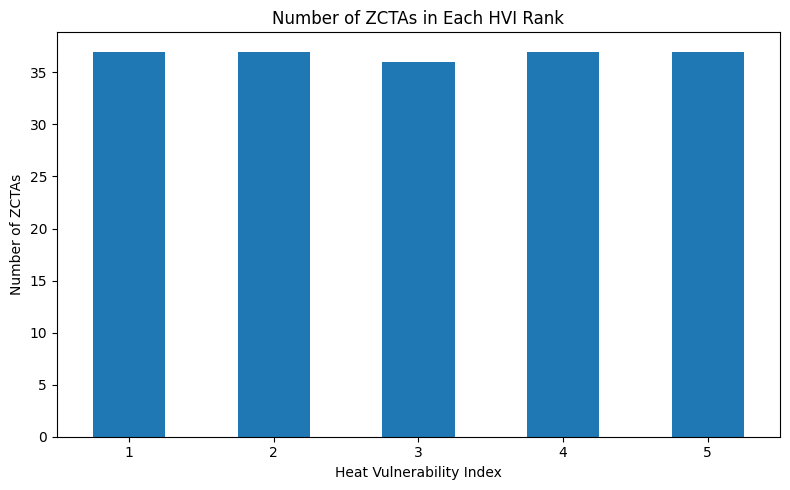

In [9]:
hvi_counts = analysis["HVI"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
hvi_counts.plot(kind="bar", ax=ax)
ax.set_title("Number of ZCTAs in Each HVI Rank")
ax.set_xlabel("Heat Vulnerability Index")
ax.set_ylabel("Number of ZCTAs")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_hvi_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

A boxplot preserves variation among individual ZCTAs and shows whether group averages are being driven by a few outliers. Zero means no mapped NYC Parks spray shower falls inside the ZCTA, not that residents have no cooling option.

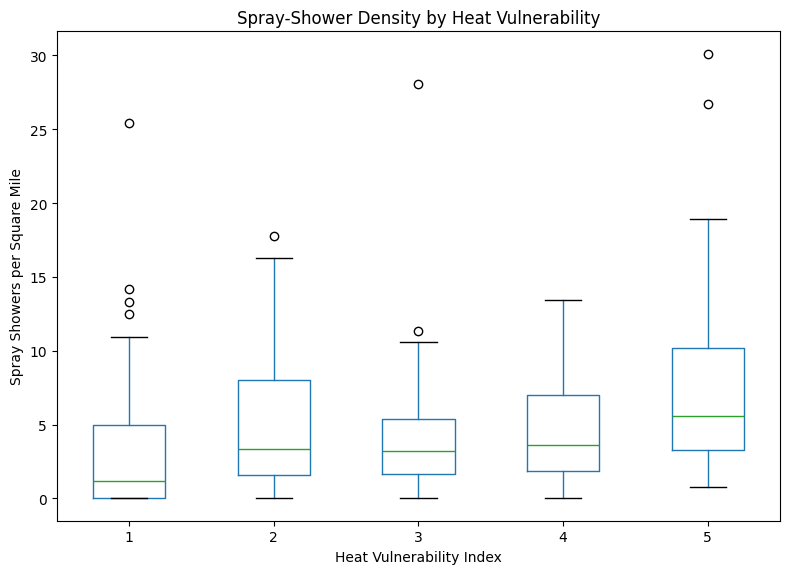

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
analysis.boxplot(column="spray_showers_per_sq_mile", by="HVI", ax=ax, grid=False)
ax.set_title("Spray-Shower Density by Heat Vulnerability")
ax.set_xlabel("Heat Vulnerability Index")
ax.set_ylabel("Spray Showers per Square Mile")
plt.suptitle("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_density_by_hvi_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

Population normalization asks how many facilities are present relative to the number of residents. The mean remains sensitive to outliers, so it should be read together with the boxplot and zero-facility share.

In [11]:
if analysis["spray_showers_per_10k"].notna().any():
    mean_per_10k = analysis.groupby("HVI")["spray_showers_per_10k"].mean()

    fig, ax = plt.subplots(figsize=(8, 5))
    mean_per_10k.plot(kind="bar", ax=ax)
    ax.set_title("Mean Spray Showers per 10,000 Residents by HVI")
    ax.set_xlabel("Heat Vulnerability Index")
    ax.set_ylabel("Mean Spray Showers per 10,000 Residents")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "06_mean_per_10k_by_hvi.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Population-normalized plot skipped because population is unavailable.")

Population-normalized plot skipped because population is unavailable.


The zero-facility share asks what percentage of ZCTAs in each HVI group contain no mapped spray shower. A point located just across a ZCTA boundary may still be nearby, so this remains a boundary-based screening measure rather than a walking-access measure.

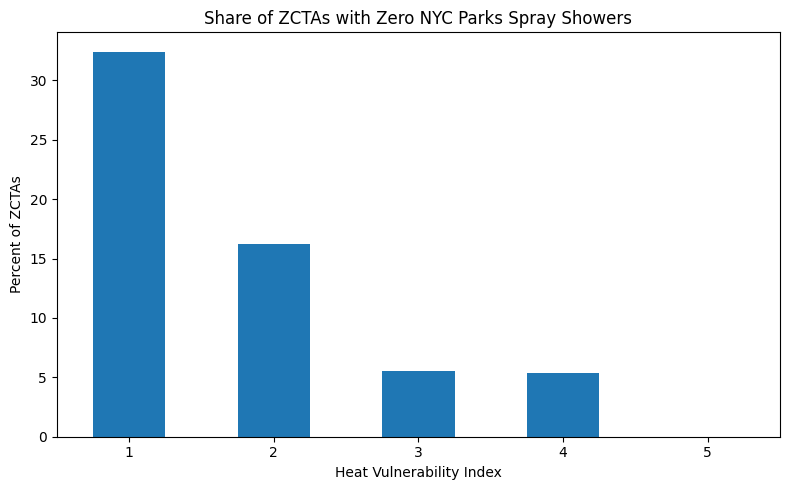

In [12]:
zero_share = (
    analysis.assign(zero=analysis["spray_shower_count"].eq(0))
    .groupby("HVI")["zero"]
    .mean()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 5))
zero_share.plot(kind="bar", ax=ax)
ax.set_title("Share of ZCTAs with Zero NYC Parks Spray Showers")
ax.set_xlabel("Heat Vulnerability Index")
ax.set_ylabel("Percent of ZCTAs")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_zero_spray_share_by_hvi.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Numeric summary and association

The table compares raw counts, area density, population rate, and the share of ZCTAs with zero facilities. Different denominators answer different questions.

I also calculate Spearman rank correlations because HVI is ordinal. Correlation is descriptive: it does not establish causation or account for spatial autocorrelation.

In [13]:
summary = analysis.groupby("HVI").agg(
    zcta_count=("ZCTA", "count"),
    total_spray_showers=("spray_shower_count", "sum"),
    mean_spray_count=("spray_shower_count", "mean"),
    median_spray_count=("spray_shower_count", "median"),
    mean_per_sq_mile=("spray_showers_per_sq_mile", "mean"),
    median_per_sq_mile=("spray_showers_per_sq_mile", "median"),
    mean_per_10k=("spray_showers_per_10k", "mean"),
    median_per_10k=("spray_showers_per_10k", "median"),
    zero_spray_share_pct=("spray_shower_count", lambda s: s.eq(0).mean() * 100),
)

display(summary.round(2))
summary.to_csv(OUTPUT_DIR / "summary_by_hvi.csv")

correlation_rows = []
for metric in [
    "spray_shower_count",
    "spray_showers_per_sq_mile",
    "spray_showers_per_10k",
]:
    subset = analysis[["HVI", metric]].dropna()
    if len(subset) > 1:
        correlation_rows.append(
            {
                "Metric": metric,
                "Spearman correlation with HVI": subset["HVI"].corr(
                    subset[metric], method="spearman"
                ),
                "Observations": len(subset),
            }
        )

correlations = pd.DataFrame(correlation_rows)
display(correlations.round(3))

,zcta_count,total_spray_showers,mean_spray_count,median_spray_count,mean_per_sq_mile,median_per_sq_mile,mean_per_10k,median_per_10k,zero_spray_share_pct
HVI,,,,,,,,,
1,37,123,3.32,2.00,3.63,1.17,NaN,NaN,32.43
2,37,207,5.59,6.00,5.29,3.37,NaN,NaN,16.22
3,36,195,5.42,4.50,4.59,3.24,NaN,NaN,5.56
4,37,263,7.11,7.00,4.82,3.65,NaN,NaN,5.41
5,37,314,8.49,7.00,7.90,5.56,NaN,NaN,0.00


,Metric,Spearman correlation with HVI,Observations
0,spray_shower_count,0.36,184
1,spray_showers_per_sq_mile,0.29,184


## 11. Potentially underserved high-HVI ZCTAs

The next table isolates HVI 4–5 ZCTAs and ranks them by the population-normalized rate when population data are available; otherwise, it uses area density. This is an exploratory priority list, not a definitive policy ranking.

In [14]:
high_hvi = analysis[analysis["HVI"].isin([4, 5])].copy()

priority_metric = (
    "spray_showers_per_10k"
    if high_hvi["spray_showers_per_10k"].notna().any()
    else "spray_showers_per_sq_mile"
)

priority_columns = [
    "ZCTA",
    "HVI",
    "spray_shower_count",
    "area_sq_mile",
    "population_2020",
    "spray_showers_per_sq_mile",
    "spray_showers_per_10k",
]

potentially_underserved = (
    high_hvi[priority_columns]
    .sort_values([priority_metric, "HVI"], ascending=[True, False])
    .head(20)
)

display(potentially_underserved.round(2))
potentially_underserved.to_csv(
    OUTPUT_DIR / "potentially_underserved_high_hvi_zctas.csv", index=False
)

,ZCTA,HVI,spray_shower_count,area_sq_mile,population_2020,spray_showers_per_sq_mile,spray_showers_per_10k
50,10475,4,0,1.31,NaN,0.00,NaN
73,11428,4,0,0.83,NaN,0.00,NaN
134,11429,5,1,1.32,NaN,0.76,NaN
115,11413,4,3,3.03,NaN,0.99,NaN
72,11412,5,2,1.66,NaN,1.21,NaN
124,11210,5,2,1.65,NaN,1.21,NaN
167,11436,5,1,0.80,NaN,1.25,NaN
80,11204,4,2,1.58,NaN,1.26,NaN
110,11219,4,2,1.49,NaN,1.34,NaN
117,11420,4,3,2.10,NaN,1.43,NaN


## 12. Automatically generated descriptive observations

In [15]:
available_metric = (
    "spray_showers_per_10k"
    if analysis["spray_showers_per_10k"].notna().any()
    else "spray_showers_per_sq_mile"
)

metric_label = {
    "spray_showers_per_10k": "spray showers per 10,000 residents",
    "spray_showers_per_sq_mile": "spray showers per square mile",
}[available_metric]

means = analysis.groupby("HVI")[available_metric].mean()
highest_group = means.idxmax()
lowest_group = means.idxmin()

overall_zero = analysis["spray_shower_count"].eq(0).mean() * 100
high_zero = (
    analysis.loc[analysis["HVI"].isin([4, 5]), "spray_shower_count"].eq(0).mean() * 100
)

lines = [
    "### Descriptive observations",
    "",
    f"- The highest average **{metric_label}** occurs in HVI category **{highest_group}**.",
    f"- The lowest average **{metric_label}** occurs in HVI category **{lowest_group}**.",
    f"- **{overall_zero:.1f}%** of all analyzed ZCTAs contain zero mapped NYC Parks spray showers.",
    f"- Among HVI 4–5 ZCTAs, **{high_zero:.1f}%** contain zero mapped spray showers.",
    "- These values describe facilities inside ZCTA boundaries and do not measure walking time, capacity, operating status, or other cooling resources.",
]

display(Markdown("\n".join(lines)))

### Descriptive observations

- The highest average **spray showers per square mile** occurs in HVI category **5**.
- The lowest average **spray showers per square mile** occurs in HVI category **1**.
- **12.0%** of all analyzed ZCTAs contain zero mapped NYC Parks spray showers.
- Among HVI 4–5 ZCTAs, **2.7%** contain zero mapped spray showers.
- These values describe facilities inside ZCTA boundaries and do not measure walking time, capacity, operating status, or other cooling resources.

## 13. Interpretation and limitations

### What the combined analysis can show

The analysis can identify clusters of high heat vulnerability, compare the relative distribution of one public cooling resource, and flag high-HVI ZCTAs for closer investigation.

### What it cannot prove

It cannot by itself prove that cooling access is equitable or inequitable. A stronger analysis would include:

- pedestrian-network travel time rather than ZCTA containment;
- operating schedules, maintenance status, capacity, and accessibility;
- cooling centers, pools, libraries, fountains, tree canopy, and household air conditioning;
- demographic characteristics such as age, disability, housing quality, and outdoor-worker exposure;
- spatial statistical methods that account for neighboring areas.

### Geographic limitation

ZCTAs are analytical approximations of ZIP Codes, not neighborhoods. A facility outside a person's ZCTA may be closer than one inside it. Results should therefore be interpreted as a citywide exploratory screening analysis.

### Conclusion

HVI represents **relative neighborhood need**, while spray-shower locations represent one observable component of **public cooling supply**. Comparing them is a useful starting point for studying cooling equity, but it should guide further research rather than serve as a final judgment.